<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/01_data_exploration/blob/main/02_radiographie_covid_classification_XGBoost_Houssein_PCA200_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification radiographies COVID-19 — XGBoost + PCA (Colab)

Ce notebook reprend les choix qui ont le mieux tenu jusque-là :
- **masques pulmonaires**
- **grayscale + CLAHE**
- **resize 128×128** pour rester compatible RAM Colab
- **PCA = 200 composantes**
- **XGBoost** multiclasses avec **early stopping**
- **évolution train / validation** via `evals_result()`
- **CV = 3** sur l'ensemble train/validation
- sorties classiques : **classification report** + **confusion matrix**

> Le notebook active automatiquement le **GPU** pour XGBoost si Colab expose CUDA.


In [ ]:
# =========================
# Installation (Colab)
# =========================
!pip -q install -U xgboost kagglehub scikit-learn opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 52.5 MB/s eta 0:00:00


In [ ]:
# =========================
# Imports et environnement
# =========================
import os
import gc
import cv2
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import kagglehub
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    HAS_TORCH = True
    USE_GPU = torch.cuda.is_available()
except Exception:
    HAS_TORCH = False
    USE_GPU = False

print("xgboost version:", xgb.__version__)
print("GPU disponible:", USE_GPU)
if USE_GPU and HAS_TORCH:
    print("GPU:", torch.cuda.get_device_name(0))


xgboost version: 3.2.0
GPU disponible: True
GPU: Tesla T4


In [ ]:
# =========================
# Configuration
# =========================
TARGET_SIZE = 128
APPLY_CLAHE = True
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

CATEGORIES = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

# Léger bonus de poids pour COVID (optionnel)
COVID_EXTRA_WEIGHT = 1.10

# PCA
N_COMPONENTS = 200

# XGBoost
XGB_PARAMS = {
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_estimators": 800,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "gamma": 0.0,
    "tree_method": "hist",
    "device": "cuda" if USE_GPU else "cpu",
    "random_state": SEED,
    "early_stopping_rounds": 30,
}

print("Configuration chargée.")
print("Resize:", TARGET_SIZE, "x", TARGET_SIZE)
print("PCA components:", N_COMPONENTS)
print("XGBoost device:", XGB_PARAMS["device"])


Configuration chargée.
Resize: 128 x 128
PCA components: 200
XGBoost device: cuda


In [ ]:
# =========================
# Téléchargement dataset Kaggle
# =========================
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
base_path = Path(path)
data_path = base_path / "COVID-19_Radiography_Dataset"

print("Dataset téléchargé dans:", base_path)
print("Data path:", data_path)


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset téléchargé dans: /kaggle/input/covid19-radiography-database
Data path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [ ]:
# =========================
# Chemins images / masques
# =========================
image_paths = {}

for category in CATEGORIES:
    image_paths[f"{category}_images"] = data_path / category / "images"
    image_paths[f"{category}_masks"] = data_path / category / "masks"

for key, value in image_paths.items():
    print(f"{key}: {value}")


COVID_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images
COVID_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/masks
Normal_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images
Normal_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks
Lung_Opacity_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/images
Lung_Opacity_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/masks
Viral Pneumonia_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images
Viral Pneumonia_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/masks


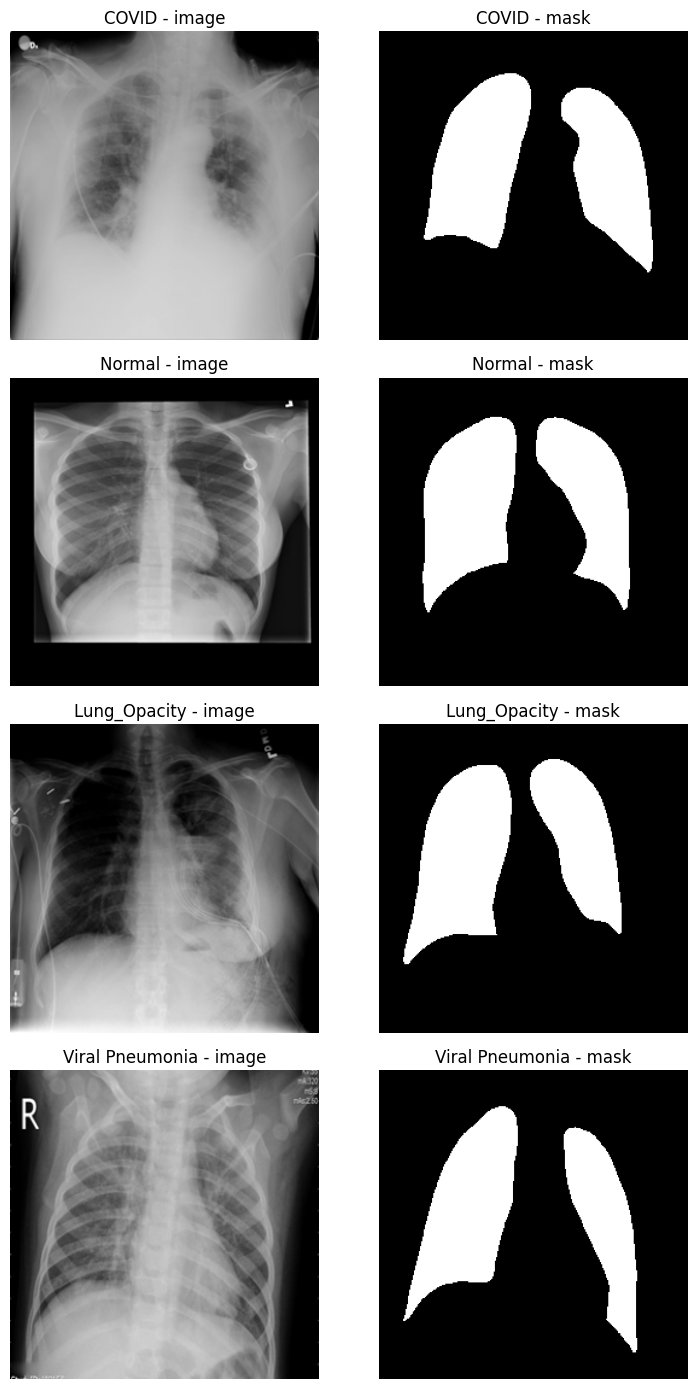

In [ ]:
# =========================
# Vérification rapide visuelle
# =========================
fig, axes = plt.subplots(len(CATEGORIES), 2, figsize=(8, 14))

for i, category in enumerate(CATEGORIES):
    image_dir = image_paths[f"{category}_images"]
    mask_dir = image_paths[f"{category}_masks"]

    files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    sample_file = files[0]

    img = cv2.imread(str(image_dir / sample_file), cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(str(mask_dir / sample_file), cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{category} - image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(msk, cmap="gray")
    axes[i, 1].set_title(f"{category} - mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# =========================
# Préprocessing
# =========================
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_SIZE)

def preprocess_image_and_mask(image_path, mask_path, target_size=128, apply_clahe=True):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        return None

    # Resize image et masque à la même taille cible
    img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)

    # Binarisation masque puis application
    mask = (mask > 0).astype(np.uint8)
    img = img * mask

    if apply_clahe:
        img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0
    return img

features_list = []
labels_list = []
skipped = 0

for category in CATEGORIES:
    image_dir = image_paths[f"{category}_images"]
    mask_dir = image_paths[f"{category}_masks"]

    print(f"Processing {category}...")
    for img_filename in os.listdir(image_dir):
        if not img_filename.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        image_path = image_dir / img_filename
        mask_path = mask_dir / img_filename

        if not mask_path.exists():
            skipped += 1
            continue

        arr = preprocess_image_and_mask(image_path, mask_path, TARGET_SIZE, APPLY_CLAHE)
        if arr is None:
            skipped += 1
            continue

        features_list.append(arr.flatten())
        labels_list.append(category)

print("Images retenues:", len(features_list))
print("Images ignorées:", skipped)


Processing COVID...
Processing Normal...
Processing Lung_Opacity...
Processing Viral Pneumonia...
Images retenues: 21165
Images ignorées: 0


In [ ]:
# =========================
# Construction X / y
# =========================
X = np.asarray(features_list, dtype=np.float32)
y_str = np.asarray(labels_list)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)
classes = list(label_encoder.classes_)

print("Classes:", classes)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("RAM approximative X:", round(X.nbytes / (1024**3), 3), "GB")

class_counts = pd.Series(y_str).value_counts().sort_index()
display(class_counts.to_frame("count"))


Classes: [np.str_('COVID'), np.str_('Lung_Opacity'), np.str_('Normal'), np.str_('Viral Pneumonia')]
X shape: (21165, 16384)
y shape: (21165,)
RAM approximative X: 1.292 GB


,count
COVID,3616
Lung_Opacity,6012
Normal,10192
Viral Pneumonia,1345


In [ ]:
# =========================
# Split train / val / test
# =========================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=SEED, stratify=y_trainval
)

print("Train   :", X_train.shape, y_train.shape)
print("Val     :", X_val.shape, y_val.shape)
print("Test    :", X_test.shape, y_test.shape)


Train   : (13545, 16384) (13545,)
Val     : (3387, 16384) (3387,)
Test    : (4233, 16384) (4233,)


In [ ]:
# =========================
# Standardisation + PCA (fit sur train uniquement)
# =========================
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_val_scaled = scaler_final.transform(X_val)
X_test_scaled = scaler_final.transform(X_test)

pca_final = PCA(n_components=N_COMPONENTS, svd_solver="randomized", random_state=SEED)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_val_pca = pca_final.transform(X_val_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("X_train_pca:", X_train_pca.shape)
print("Variance expliquée cumulée:", round(pca_final.explained_variance_ratio_.sum(), 4))


X_train_pca: (13545, 200)
Variance expliquée cumulée: 0.7823


## Validation croisée CV=3

On refait **scaler + PCA + XGBoost** dans chaque fold pour éviter la fuite de données.


In [ ]:
# =========================
# CV = 3 sur trainval
# =========================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_rows = []
covid_idx = classes.index("COVID") if "COVID" in classes else 0

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval, y_trainval), start=1):
    X_tr, X_va = X_trainval[tr_idx], X_trainval[va_idx]
    y_tr, y_va = y_trainval[tr_idx], y_trainval[va_idx]

    scaler_cv = StandardScaler()
    X_tr_s = scaler_cv.fit_transform(X_tr)
    X_va_s = scaler_cv.transform(X_va)

    pca_cv = PCA(n_components=N_COMPONENTS, svd_solver="randomized", random_state=SEED)
    X_tr_p = pca_cv.fit_transform(X_tr_s)
    X_va_p = pca_cv.transform(X_va_s)

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_tr).astype(np.float32)
    sample_weight[y_tr == covid_idx] *= COVID_EXTRA_WEIGHT

    model_cv = xgb.XGBClassifier(
        **XGB_PARAMS,
        num_class=len(classes),
    )

    model_cv.fit(
        X_tr_p, y_tr,
        sample_weight=sample_weight,
        eval_set=[(X_tr_p, y_tr), (X_va_p, y_va)],
        verbose=False,
    )

    pred_va = model_cv.predict(X_va_p)
    fold_f1 = f1_score(y_va, pred_va, average="macro")
    fold_covid_recall = recall_score(y_va, pred_va, labels=[covid_idx], average=None)[0]

    cv_rows.append({
        "fold": fold,
        "best_iteration": int(getattr(model_cv, "best_iteration", model_cv.n_estimators)),
        "val_macro_f1": fold_f1,
        "val_covid_recall": fold_covid_recall,
    })

cv_results = pd.DataFrame(cv_rows)
display(cv_results)
print("CV macro-F1 mean:", round(cv_results["val_macro_f1"].mean(), 4))
print("CV COVID recall mean:", round(cv_results["val_covid_recall"].mean(), 4))


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [05:53:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,fold,best_iteration,val_macro_f1,val_covid_recall
0,1,577,0.693996,0.377202
1,2,604,0.699197,0.374481
2,3,570,0.687241,0.359959


CV macro-F1 mean: 0.6935
CV COVID recall mean: 0.3705


## Entraînement final avec early stopping

On entraîne sur **train**, on surveille **validation**, puis on évalue sur **test**.


In [ ]:
# =========================
# Entraînement final XGBoost
# =========================
sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train).astype(np.float32)
sample_weight_train[y_train == covid_idx] *= COVID_EXTRA_WEIGHT

final_model = xgb.XGBClassifier(
    **XGB_PARAMS,
    num_class=len(classes),
)

start_time = time.time()
final_model.fit(
    X_train_pca, y_train,
    sample_weight=sample_weight_train,
    eval_set=[(X_train_pca, y_train), (X_val_pca, y_val)],
    verbose=25,
)
training_time = time.time() - start_time

print(f"Temps d'entraînement: {training_time:.2f} s")
print("Best iteration:", getattr(final_model, "best_iteration", None))


[0]	validation_0-mlogloss:1.37044	validation_1-mlogloss:1.37432
[25]	validation_0-mlogloss:1.00019	validation_1-mlogloss:1.08237
[50]	validation_0-mlogloss:0.81796	validation_1-mlogloss:0.96149
[75]	validation_0-mlogloss:0.69920	validation_1-mlogloss:0.89138
[100]	validation_0-mlogloss:0.60736	validation_1-mlogloss:0.84447
[125]	validation_0-mlogloss:0.53478	validation_1-mlogloss:0.81189
[150]	validation_0-mlogloss:0.47290	validation_1-mlogloss:0.78742
[175]	validation_0-mlogloss:0.41968	validation_1-mlogloss:0.76778
[200]	validation_0-mlogloss:0.37686	validation_1-mlogloss:0.75235
[225]	validation_0-mlogloss:0.33938	validation_1-mlogloss:0.73920
[250]	validation_0-mlogloss:0.30448	validation_1-mlogloss:0.72701
[275]	validation_0-mlogloss:0.27533	validation_1-mlogloss:0.71751
[300]	validation_0-mlogloss:0.24904	validation_1-mlogloss:0.70833
[325]	validation_0-mlogloss:0.22558	validation_1-mlogloss:0.70212
[350]	validation_0-mlogloss:0.20584	validation_1-mlogloss:0.69646
[375]	validatio

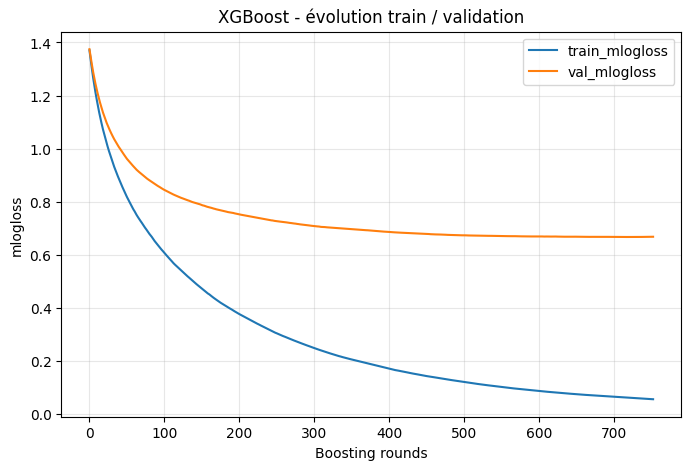

In [ ]:
# =========================
# Courbes train / validation
# =========================
results = final_model.evals_result()

train_key = list(results["validation_0"].keys())[0]
val_key = list(results["validation_1"].keys())[0]

train_curve = results["validation_0"][train_key]
val_curve = results["validation_1"][val_key]

plt.figure(figsize=(8, 5))
plt.plot(train_curve, label=f"train_{train_key}")
plt.plot(val_curve, label=f"val_{val_key}")
plt.xlabel("Boosting rounds")
plt.ylabel(train_key)
plt.title("XGBoost - évolution train / validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


                 precision    recall  f1-score   support

          COVID     0.6088    0.4025    0.4846       723
   Lung_Opacity     0.6917    0.7273    0.7091      1203
         Normal     0.7849    0.8646    0.8228      2038
Viral Pneumonia     0.8857    0.8067    0.8444       269

       accuracy                         0.7430      4233
      macro avg     0.7428    0.7003    0.7152      4233
   weighted avg     0.7347    0.7430    0.7341      4233



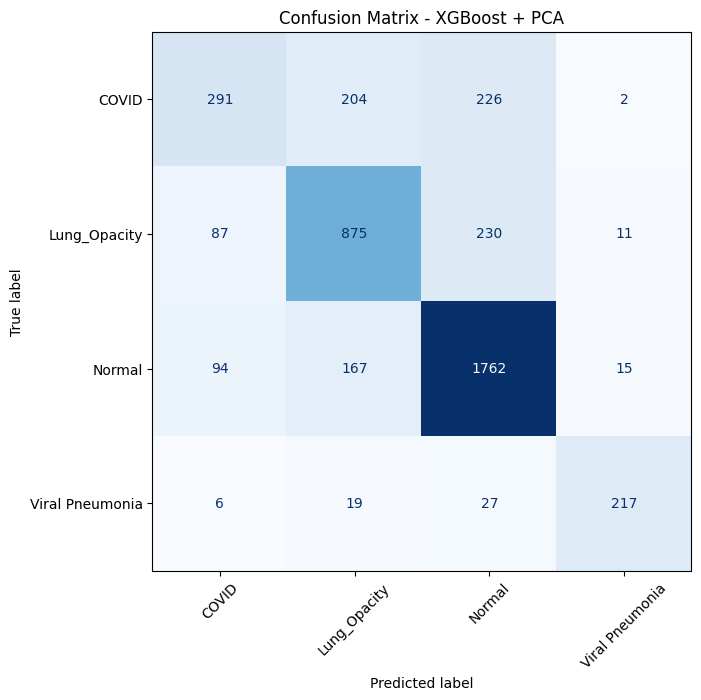

,precision,recall,f1-score,support
COVID,0.608787,0.402490,0.484596,723.000000
Lung_Opacity,0.691700,0.727348,0.709076,1203.000000
Normal,0.784855,0.864573,0.822788,2038.000000
Viral Pneumonia,0.885714,0.806691,0.844358,269.000000
accuracy,0.742972,0.742972,0.742972,0.742972
macro avg,0.742764,0.700276,0.715205,4233.000000
weighted avg,0.734718,0.742972,0.734079,4233.000000


Test macro-F1: 0.7152
Test COVID recall: 0.4025


In [ ]:
# =========================
# Évaluation test
# =========================
y_pred = final_model.predict(X_test_pca)

print(classification_report(y_test, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - XGBoost + PCA")
plt.show()

report_dict = classification_report(y_test, y_pred, target_names=classes, output_dict=True, digits=4)
report_df = pd.DataFrame(report_dict).T
display(report_df)

test_macro_f1 = f1_score(y_test, y_pred, average="macro")
test_covid_recall = recall_score(y_test, y_pred, labels=[covid_idx], average=None)[0]

print("Test macro-F1:", round(test_macro_f1, 4))
print("Test COVID recall:", round(test_covid_recall, 4))


In [ ]:
# =========================
# Sauvegarde optionnelle
# =========================
# Le modèle XGBoost se sauvegarde séparément de PCA/scaler
# final_model.save_model("xgboost_covid_pca200.json")

# Exemple pour sauvegarder le scaler + PCA
# import joblib
# joblib.dump(scaler_final, "scaler_xgb.pkl")
# joblib.dump(pca_final, "pca200_xgb.pkl")
print("Notebook terminé.")


Notebook terminé.
